In [1]:
import sys
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F

# still do preprocessing in scipy
import scipy.sparse as sp

from importlib import reload

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/splicing-VAE')
import VAE_model
reload(VAE_model)

import matplotlib.pyplot as plt

In [2]:
# review https://sebastiancallh.github.io/post/vae-anatomy/

In [3]:
leaflet_repo = '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/'
sys.path.append(leaflet_repo)
import load_cluster_data
from betabinomo_mix_singlecells import *

### Settings and Load data

In [4]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cpu


In [5]:
device

device(type='cpu')

In [6]:
input_files_folder = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/'

cell_types = ['Brain_Non-Myeloid_brain_pericyte','Brain_Non-Myeloid_oligodendrocyte_precursor_cell','Brain_Non-Myeloid_endothelial_cell','Brain_Non-Myeloid_oligodendrocyte',
 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage',
 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte'] #ignoring Bergmann_glial_cell since very few cells

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, celltypes=cell_types, has_genes="yes") 

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/MLCB_Brain_true/FULL/
Finished reading in data from folder ...
Looking at only specific cell types ...['Brain_Non-Myeloid_brain_pericyte', 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell', 'Brain_Non-Myeloid_endothelial_cell', 'Brain_Non-Myeloid_oligodendrocyte', 'Brain_Non-Myeloid_neuron', 'Brain_Myeloid_macrophage', 'Brain_Myeloid_microglial_cell', 'Brain_Non-Myeloid_astrocyte']
['Brain_Non-Myeloid_brain_pericyte'
 'Brain_Non-Myeloid_oligodendrocyte_precursor_cell'
 'Brain_Non-Myeloid_endothelial_cell' 'Brain_Non-Myeloid_oligodendrocyte'
 'Brain_Non-Myeloid_neuron' 'Brain_Myeloid_macrophage'
 'Brain_Myeloid_microglial_cell' 'Brain_Non-Myeloid_astrocyte']
7816
16190
The maximum junction count was initially:  150346
80
The maximum junction count is now:  4982
                                             cell_id  Cluster  Cluster_Counts  \
0  A14-MAA000581-3_10_M-1-1_Brain_Non-M

In [7]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
7816
7816


/gpfs/commons/home/kisaev/Leaflet-private/src/beta-binomial-mix/betabinomo_mix_singlecells.py:333: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [8]:
simple_data = final_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "juncratio", "junc_count", "cluster_count",  "junction_id", "gene_id"]]

### Get ready for model training 

In [9]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [10]:
# set up sparse tensor for junction counts 
indices = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(final_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = final_data['cell_id_index'].max() + 1
num_junctions = final_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [11]:
# set up sparse tensor for cluster counts
indices_counts = torch.tensor(final_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(final_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = final_data['cell_id_index'].max() + 1
num_junctions_counts = final_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [12]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [13]:
# check if train_loader is on cuda
torch.cuda.is_available()

False

In [14]:
# Example usage:
junction_tensor, intron_tensor = y_tensor, total_counts_tensor

In [16]:
total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  7815,  7815,  7815],
                       [    0,     1,     2,  ..., 15889, 15903, 15921]]),
       values=tensor([21., 21., 16.,  ..., 31., 29., 31.]),
       size=(7816, 15929), nnz=10546354, layout=torch.sparse_coo)

In [22]:
10546354 / (7816*15929)

0.084708946744423

In [15]:
# input --> junction usage ratios (PSI)
# output --> junction counts via inferred PSI and total counts

In [70]:
reload(VAE_model)
from VAE_model import *

In [100]:
# Configuration
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
BATCH_SIZE = 512
USE_CUDA = torch.cuda.is_available()
print(USE_CUDA)

INPUT_DIM = junction_tensor.shape[1]
HIDDEN_DIMS = [128, 64, 32]  # Example dimensions, adjust as needed
Z_DIM = 50
OUTPUT_DIM = INPUT_DIM  # Assuming output dimension matches input
perc_train = 0.8

True


In [101]:
train_loader, test_loader, full_dat = setup_data_loaders(junction_tensor, intron_tensor, BATCH_SIZE, USE_CUDA, perc_train)

model = VAE(INPUT_DIM, HIDDEN_DIMS, Z_DIM, OUTPUT_DIM)
model.train()

optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

Percentage of data used for training:  0.8


In [102]:
model

VAE(
  (encoder): Encoder(
    (body): Sequential(
      (0): Linear(in_features=15929, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
    (linear_means): Linear(in_features=32, out_features=50, bias=True)
    (linear_log_var): Linear(in_features=32, out_features=50, bias=True)
  )
  (decoder): Decoder(
    (body): Sequential(
      (0): Linear(in_features=50, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momen

In [103]:
# best validation loss 
best_val_loss = float('inf')
max_patience = 2
best_epoch = 0
train_losses = []
val_losses = []

# Training Loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"Epoch {epoch}")
    avg_train_loss = train(model, train_loader, optimizer, epoch)
    avg_val_loss = evaluate(model, test_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        patience = max_patience
    else:
        patience -= 1
        if patience == 0:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1
====> Epoch: 1 Average training loss: 1.1693
====> Evaluation set average loss: 0.0783
Epoch 2
====> Epoch: 2 Average training loss: 0.1728
====> Evaluation set average loss: 0.0401
Epoch 3
====> Epoch: 3 Average training loss: 0.0976
====> Evaluation set average loss: 0.0343
Epoch 4
====> Epoch: 4 Average training loss: 0.0734
====> Evaluation set average loss: 0.0329
Epoch 5
====> Epoch: 5 Average training loss: 0.0608
====> Evaluation set average loss: 0.0320
Epoch 6
====> Epoch: 6 Average training loss: 0.0516
====> Evaluation set average loss: 0.0316
Epoch 7
====> Epoch: 7 Average training loss: 0.0461
====> Evaluation set average loss: 0.0313
Epoch 8
====> Epoch: 8 Average training loss: 0.0412
====> Evaluation set average loss: 0.0311
Epoch 9
====> Epoch: 9 Average training loss: 0.0397
====> Evaluation set average loss: 0.0307
Epoch 10
====> Epoch: 10 Average training loss: 0.0367
====> Evaluation set average loss: 0.0307
Epoch 11
====> Epoch: 11 Average training loss: 

In [104]:
# why is it when i increase latent space z dim, the validation loss is smaller than training loss?
# if i keep it at 20, the training loss is smaller than validation loss which is expected

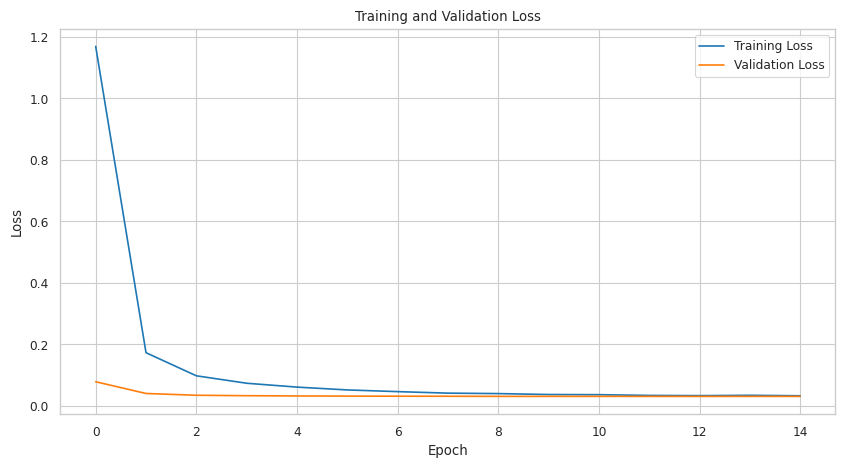

In [105]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [106]:
reload(VAE_model)
from VAE_model import *

In [107]:
model.eval()  # Set the model to evaluation mode
latent_variables = []
with torch.no_grad():
    for data in full_dat:
        inputs = data['proportions'].to(device)  # Ensure data is on the correct device
        z = model.extract_latent_variables(inputs, apply_noise=False)  # Apply_noise=False to get the mean of the latent space
        latent_variables.append(z.cpu().numpy())  # Move z to CPU and convert to numpy

latent_variables = np.concatenate(latent_variables, axis=0)

Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise applied:  False
Noise appl

In [108]:
import umap

reducer = umap.UMAP(random_state=42)
umap_embedding = reducer.fit_transform(latent_variables)

KeyboardInterrupt: 

In [ ]:
latent_variables_df = pd.DataFrame(latent_variables)
latent_variables_df

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.000732,-0.006752,-0.005680,-0.001685,-0.000411,0.009018,-0.004340,-0.001311,-0.003310,-0.001022,...,0.004979,-0.001385,0.005482,-0.015780,0.003101,0.003714,-0.000082,-0.000449,0.004650,0.003150
1,0.002693,-0.001906,-0.010790,0.002570,0.006346,0.009915,-0.007505,0.001285,0.002972,0.011543,...,0.001295,-0.006952,0.003786,-0.012693,-0.000225,0.000672,-0.001718,-0.001191,0.002178,0.003026
2,0.000491,-0.001827,-0.007818,0.002016,0.000960,0.008664,-0.007424,0.002685,-0.001551,0.006228,...,0.001980,0.004541,0.003797,-0.009161,-0.000256,0.008110,-0.003077,0.002136,0.000492,-0.003518
3,0.006196,-0.009505,-0.009694,-0.009756,-0.000392,0.008890,0.000700,0.001206,-0.008956,0.005248,...,0.007194,-0.006323,0.011389,-0.019559,0.001312,0.003587,-0.000925,-0.001138,0.001038,0.004979
4,0.002414,-0.007464,-0.007799,0.001628,0.000804,0.011747,-0.001041,0.001876,-0.000057,0.009345,...,0.004701,-0.005272,0.003128,-0.017846,-0.001250,0.001166,0.000874,0.008570,0.002131,0.002630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7811,-0.003521,-0.006172,-0.012241,0.001740,0.001234,0.007487,0.000619,0.004323,-0.001024,0.000620,...,0.004084,0.005096,0.003799,-0.019909,0.000421,0.002645,0.006829,0.000156,0.014031,0.001336
7812,-0.004147,-0.002703,-0.010575,0.001453,0.001706,0.006410,0.001624,0.004059,-0.000036,0.003003,...,0.002877,0.002843,0.003250,-0.014509,-0.000745,0.002231,0.004066,-0.001595,0.008911,0.002796
7813,-0.004516,-0.008574,-0.013415,-0.001150,-0.001734,0.004772,0.001239,0.004391,-0.000893,-0.004501,...,0.004231,0.008910,0.001368,-0.020951,0.001192,0.003445,0.005975,0.004726,0.016953,-0.001722
7814,0.000494,0.026141,-0.009857,0.022888,0.017245,0.011648,-0.012835,-0.002570,0.009088,0.040990,...,-0.001405,-0.017378,0.006093,0.004436,0.002641,0.003260,-0.002396,-0.007272,-0.009396,0.001499


In [ ]:
umap_embedding_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'])
umap_embedding_df["cell_type"] = cell_ids_conversion["cell_type"].values
umap_embedding_df.head()

,UMAP1,UMAP2,cell_type
0,-1.884510,5.898596,Brain_Non-Myeloid_brain_pericyte
1,-1.163695,5.600811,Brain_Non-Myeloid_brain_pericyte
2,-2.677997,6.430130,Brain_Non-Myeloid_brain_pericyte
3,-1.545950,6.079375,Brain_Non-Myeloid_brain_pericyte
4,-1.617093,5.839157,Brain_Non-Myeloid_brain_pericyte


<Axes: xlabel='UMAP1', ylabel='UMAP2'>

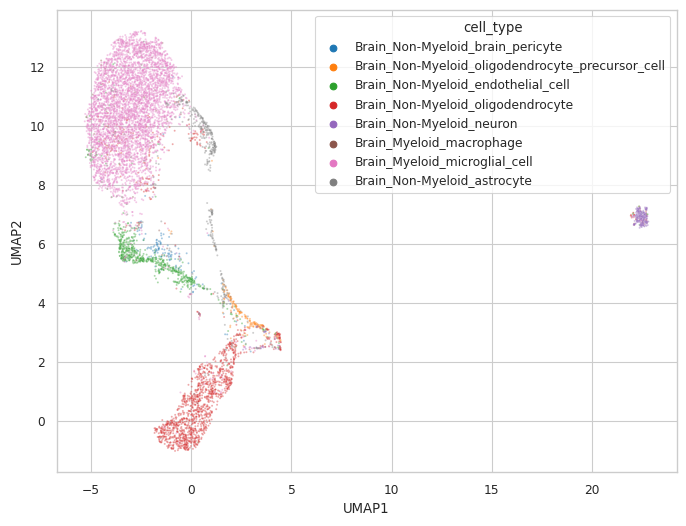

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(data=umap_embedding_df, x='UMAP1', y='UMAP2', hue='cell_type', palette='tab10', s=2, alpha=0.4)

In [ ]:
# calcualte silhouette score
from sklearn.metrics import silhouette_score
cell_types = cell_ids_conversion["cell_type"].values
silhouette_score(umap_embedding, cell_types)

0.17605351

In [ ]:
# calcualte Davies-Bouldin Index
from sklearn.metrics import davies_bouldin_score
davies_bouldin_score(umap_embedding, cell_types)

2.698205267866513

In [ ]:
model

VAE(
  (encoder): Encoder(
    (body): Sequential(
      (0): Linear(in_features=15929, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
      (8): Linear(in_features=64, out_features=32, bias=True)
      (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): Dropout(p=0.1, inplace=False)
    )
    (linear_means): Linear(in_features=32, out_features=50, bias=True)
    (linear_log_var): Linear(in_features=32, out_features=50, bias=True)
  )
  (decoder): Decoder(
    (body): Sequential(
      (0): Linear(in_features=50, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momen

In [ ]:
latent_variables

array([[ 0.000732  , -0.00675212, -0.00567989, ..., -0.00044905,
         0.00464998,  0.0031497 ],
       [ 0.00269317, -0.00190592, -0.01079017, ..., -0.00119124,
         0.0021776 ,  0.00302557],
       [ 0.00049106, -0.0018273 , -0.00781788, ...,  0.00213583,
         0.00049235, -0.00351809],
       ...,
       [-0.00451619, -0.00857379, -0.01341544, ...,  0.0047256 ,
         0.01695284, -0.00172168],
       [ 0.00049385,  0.02614121, -0.00985734, ..., -0.00727158,
        -0.00939637,  0.00149891],
       [-0.00189781, -0.00489555, -0.01143227, ..., -0.00082848,
         0.00952983, -0.00214438]], dtype=float32)

Evaluate latent variables 

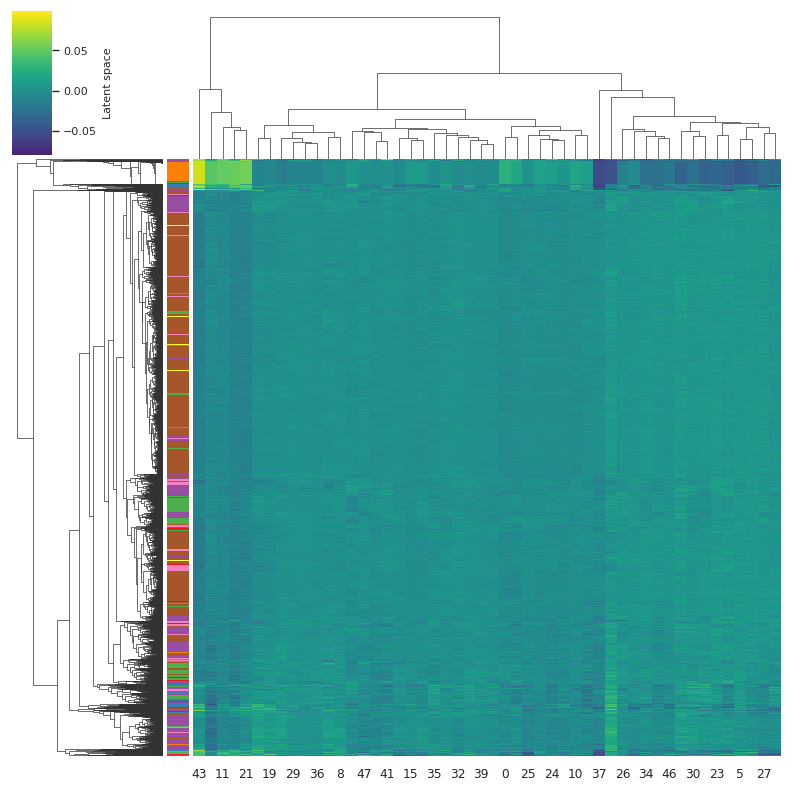

In [ ]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_ids_conversion['cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_ids_conversion['cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_ids_conversion.cell_type.values

# create colours for each cell type 
cell_type_colors = {cell_type: color for cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[cell_type] for cell_type in cell_types]

cluster = sns.clustermap(
    data=latent_variables,
    method='complete',
    cmap="viridis",
    annot=False,
    fmt=".2f",
    yticklabels=False,
    figsize=(8, 8),
    center=0,
    row_colors=row_colors,  # Apply row colors
    cbar_kws={'label': 'Latent space'} 
    )
cluster.cax.set_ylabel('Latent space', size=8)
# Increase font size for color bar tick labels:
cbar_ax = cluster.cax
for label in cbar_ax.yaxis.get_ticklabels():
    label.set_size(8)

In [ ]:
Z_DIM

50

In [ ]:
# for each cell type, get the average factor contribution
cell_type_contribs = {}
for cell_type in unique_cell_types:
    # get indices of cells of this cell type
    cell_type_indices = cell_ids_conversion[cell_ids_conversion["cell_type"] == cell_type].cell_id_index
    # get average factor contribution for these cells
    cell_type_contribs[cell_type] = latent_variables[cell_type_indices].mean(axis=0)

# make a dataframe

cell_type_contribs_df = pd.DataFrame(cell_type_contribs)
cell_type_contribs_df = cell_type_contribs_df.T
K = Z_DIM
cell_type_contribs_df.columns = ["Factor " + str(i) for i in range(K)]

cell_type_contribs_df

,Factor 0,Factor 1,Factor 2,Factor 3,Factor 4,Factor 5,Factor 6,Factor 7,Factor 8,Factor 9,...,Factor 40,Factor 41,Factor 42,Factor 43,Factor 44,Factor 45,Factor 46,Factor 47,Factor 48,Factor 49
Brain_Non-Myeloid_brain_pericyte,0.001660,-0.001382,-0.005633,0.002718,0.003513,0.007554,-0.002846,-0.001437,0.001095,0.009592,...,0.003931,-0.004167,0.003967,-0.005147,0.001146,-0.000758,-0.001288,0.001119,0.000349,0.001472
Brain_Non-Myeloid_oligodendrocyte_precursor_cell,-0.004073,0.014329,0.007969,-0.003092,0.004311,0.003678,0.004331,-0.009629,0.001495,0.018604,...,0.006035,-0.001011,0.005522,0.027366,0.003436,-0.006824,-0.012540,-0.001275,-0.017099,-0.004713
Brain_Non-Myeloid_endothelial_cell,0.001436,0.002223,-0.010743,0.002857,0.001962,0.006839,-0.004719,0.002148,0.003155,0.010262,...,0.001785,-0.001216,0.002309,-0.007868,-0.001124,0.000041,0.001306,-0.001254,0.001038,0.000818
Brain_Non-Myeloid_oligodendrocyte,-0.003190,0.004222,-0.007043,0.003196,0.004531,0.001842,0.002409,-0.000675,0.003048,0.008784,...,0.000976,0.000289,0.000118,0.000257,-0.000973,-0.001048,-0.000254,-0.003280,0.005107,-0.001375
Brain_Non-Myeloid_neuron,0.024107,-0.005950,0.047708,0.000160,-0.013832,-0.039007,0.005366,-0.005618,-0.004194,-0.040945,...,-0.000437,0.000195,-0.034070,0.078250,-0.001442,-0.029528,-0.018280,0.002290,-0.035822,-0.003607
Brain_Myeloid_macrophage,-0.002742,-0.001708,-0.009731,0.002602,0.001848,0.006180,0.000087,0.003516,0.001064,0.006780,...,0.001819,-0.000841,0.004475,-0.012969,-0.001199,0.002163,0.002937,0.000658,0.004943,0.000845
Brain_Myeloid_microglial_cell,-0.004129,-0.001027,-0.010646,0.001346,0.000759,0.005686,-0.000878,0.003762,0.001065,0.005954,...,0.000958,0.000546,0.005473,-0.013116,-0.000014,0.003616,0.004068,0.001413,0.005275,0.000140
Brain_Non-Myeloid_astrocyte,-0.000326,-0.004440,-0.010993,-0.000034,0.001886,0.005774,0.001031,0.003718,0.000221,0.004764,...,0.004221,-0.001448,0.003954,-0.013017,0.000139,0.004955,0.002648,0.001450,0.006849,0.001920


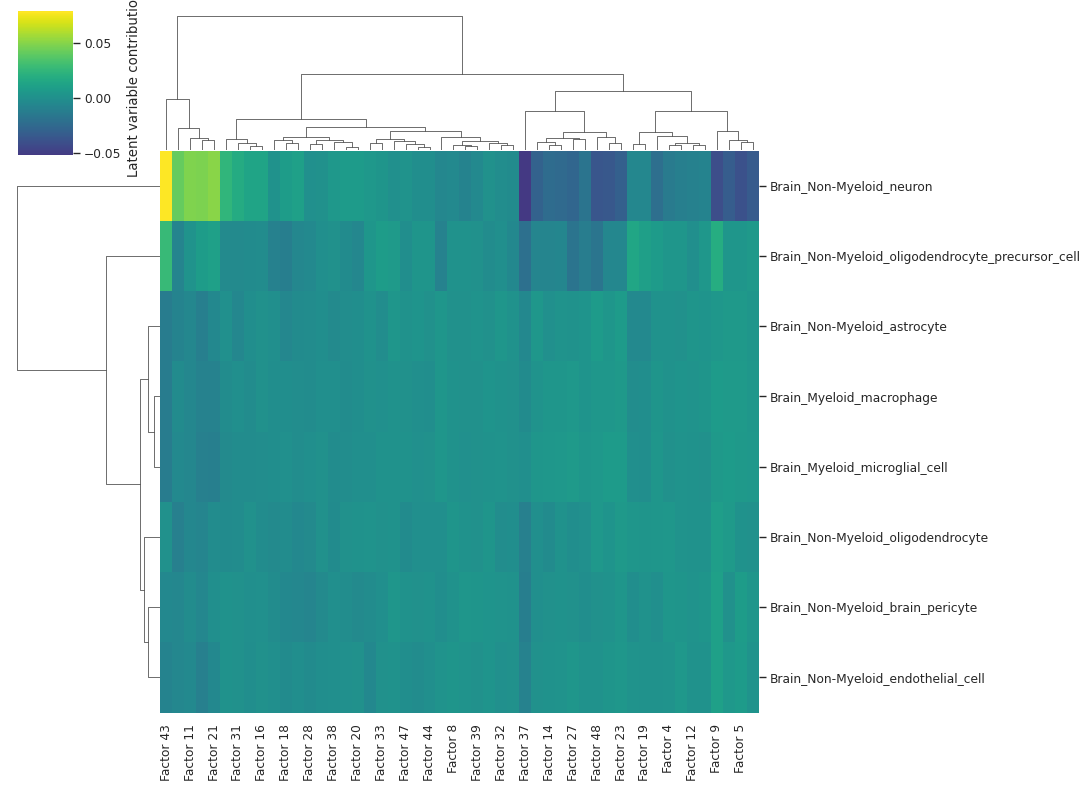

In [ ]:
# plot clustermap 
sns.set_style("whitegrid")
sns.set_context("paper")
cluster = sns.clustermap(
    data=cell_type_contribs_df,
    method='complete',
    cmap="viridis",
    annot=False,
    # make font size smaller
    annot_kws={"size": 10},
    yticklabels=True,
    figsize=(11, 8),
    center=0,
    cbar_kws={'label': 'Latent variable contribution'} 
    )